In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [5]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [6]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [7]:
df.columns = df.columns.str.strip()

In [8]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [9]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [10]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


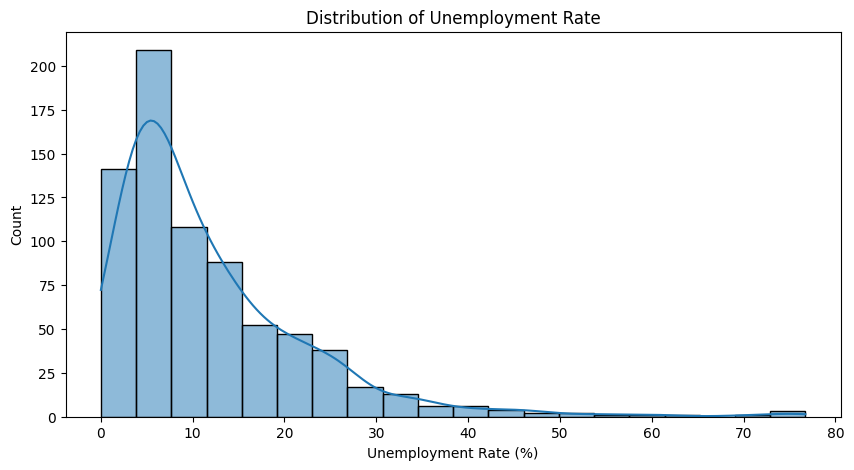

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.xlabel("Unemployment Rate (%)")

plt.ylabel("Count")

plt.show()

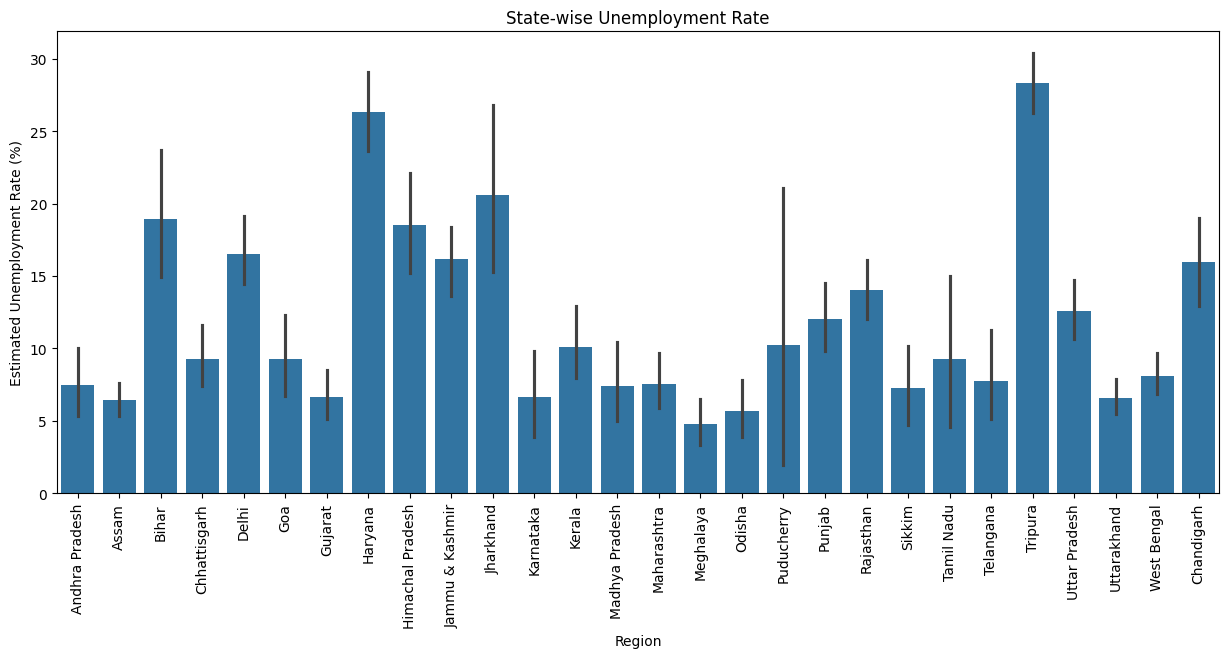

In [12]:
plt.figure(figsize=(15,6))

sns.barplot(
    x='Region',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.xticks(rotation=90)

plt.title("State-wise Unemployment Rate")

plt.show()

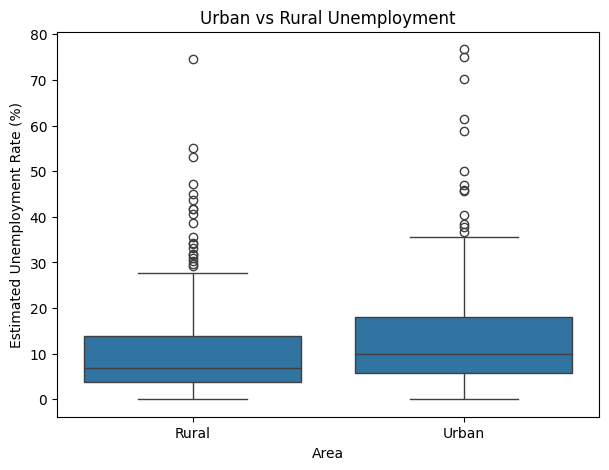

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")

plt.show()

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\hp\AppData\Local\Temp\ipykernel_8844\2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


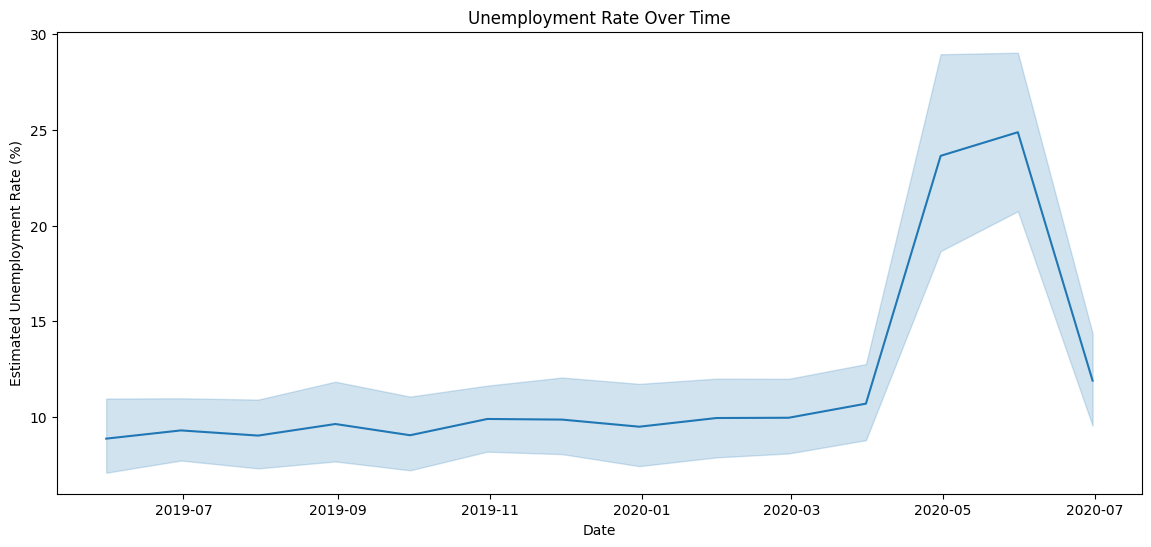

In [15]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Unemployment Rate Over Time")

plt.show()

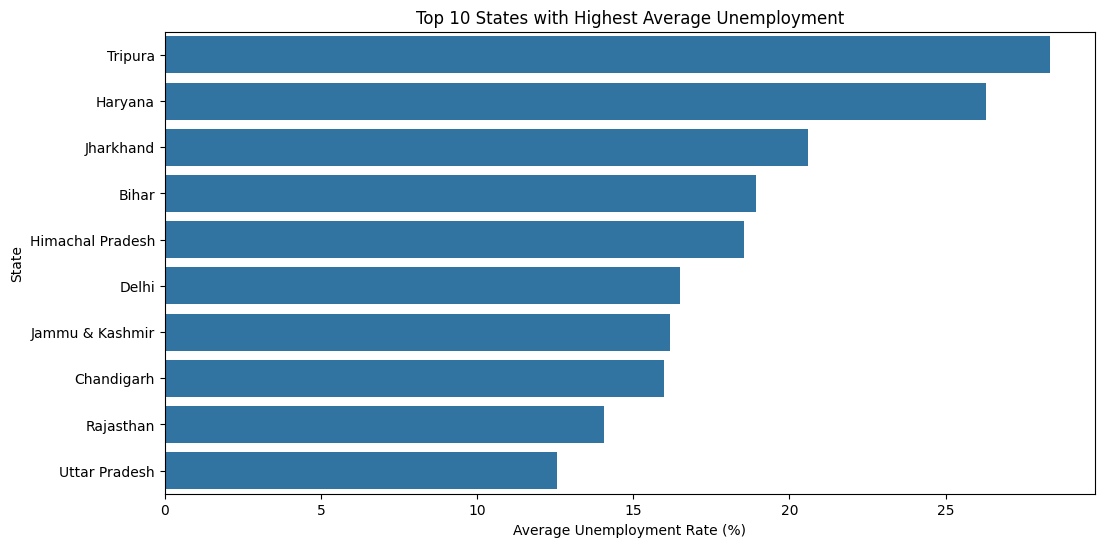

In [16]:
top_states = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States with Highest Average Unemployment")

plt.xlabel("Average Unemployment Rate (%)")

plt.ylabel("State")

plt.show()

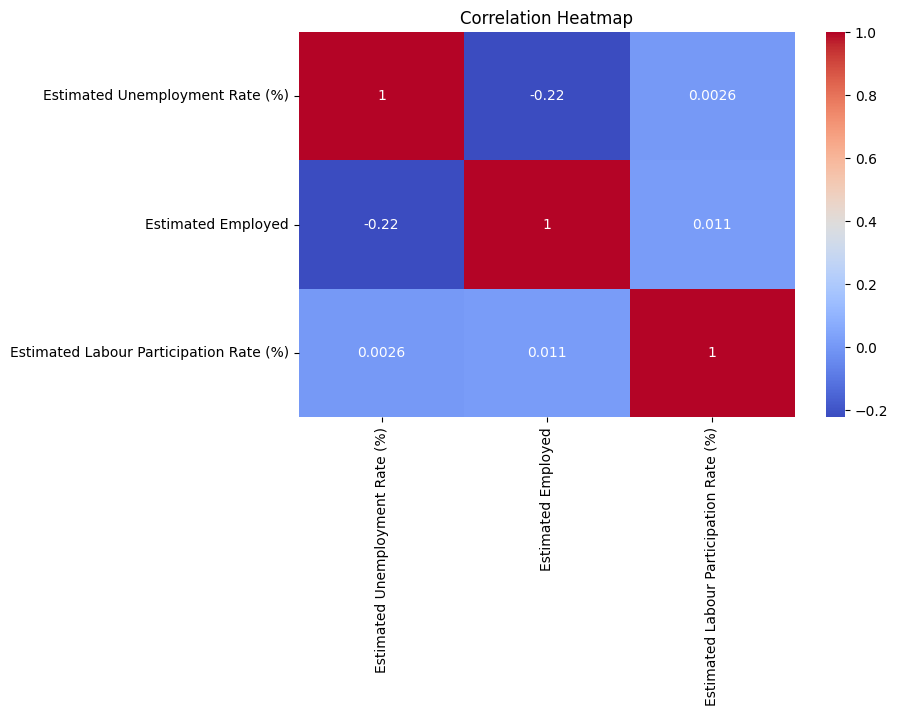

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
fig = px.scatter(
    df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    color='Region',
    size='Estimated Labour Participation Rate (%)',
    title="Interactive Unemployment Analysis"
)

fig.show()

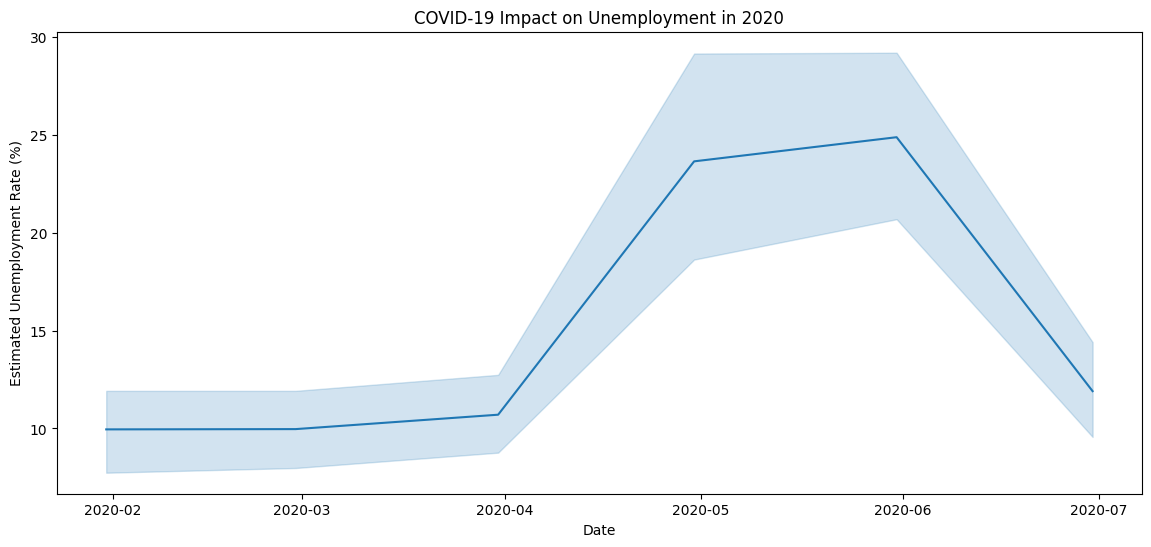

In [19]:
covid_data = df[df['Date'].dt.year == 2020]

plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_data
)

plt.title("COVID-19 Impact on Unemployment in 2020")

plt.show()

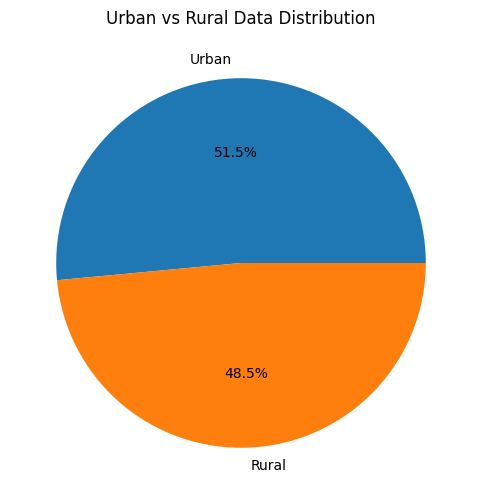

In [20]:
area_counts = df['Area'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    area_counts,
    labels=area_counts.index,
    autopct='%1.1f%%'
)

plt.title("Urban vs Rural Data Distribution")

plt.show()